In [155]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



In [157]:
k=pd.read_csv("customer_data.csv")

In [147]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy="most_frequent")
si.fit(k[["age","visits_per_month"]])

,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [148]:
c=si.transform(k[["age","visits_per_month"]])

In [149]:
k=pd.DataFrame(c,columns=["age","visits_per_month"])

In [150]:
a=pd.concat([k,df],axis=1)

In [151]:
a

,age,visits_per_month,monthly_spend,avg_discount_used,distance_from_store_km
0,56.0,18.0,5415.000000,44.000000,1.450000
1,50.0,29.0,5437.000000,19.000000,12.410000
2,32.0,15.0,759.000000,25.000000,5.890000
3,25.0,19.0,3872.000000,51.000000,12.370000
4,38.0,19.0,4783.000000,37.469444,4.160000
...,...,...,...,...,...
395,50.0,25.0,2087.000000,51.000000,7.832944
396,29.0,1.0,3255.872222,33.000000,4.340000
397,18.0,22.0,866.000000,40.000000,9.860000
398,18.0,23.0,4388.000000,56.000000,9.140000


In [152]:
scaler = StandardScaler()
scaled = scaler.fit_transform(a)

In [153]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(scaled)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [100]:
dropped_df=df.dropna()

In [101]:
scaler = StandardScaler()
scaled = scaler.fit_transform(dropped_df)

In [102]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(scaled)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


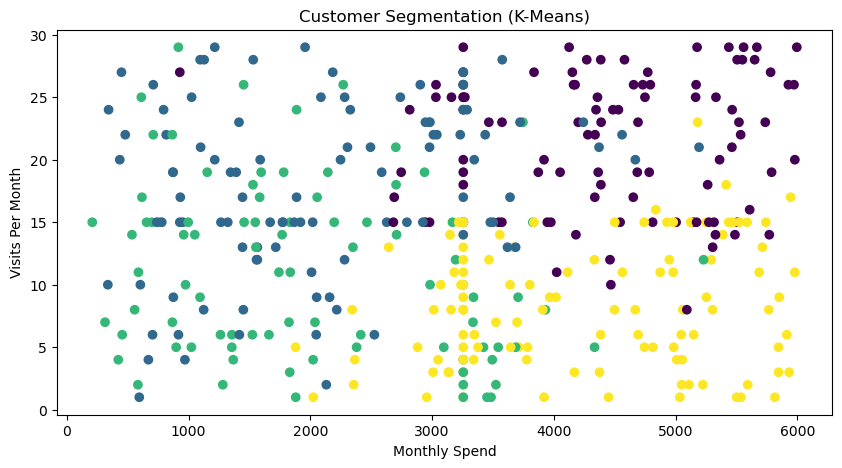

Segmented data saved as segmented_customers.csv


In [156]:
plt.figure(figsize=(10,5))
plt.scatter(a["monthly_spend"], a["visits_per_month"], c=labels)
plt.xlabel("Monthly Spend")
plt.ylabel("Visits Per Month")
plt.title("Customer Segmentation (K-Means)")
plt.show()
data.to_csv("segmented_customers.csv", index=False)
print("Segmented data saved as segmented_customers.csv")